应用截止频率为 30 的理想低通滤波器...
应用截止频率为 60 的理想低通滤波器...
应用截止频率为 120 的理想低通滤波器...


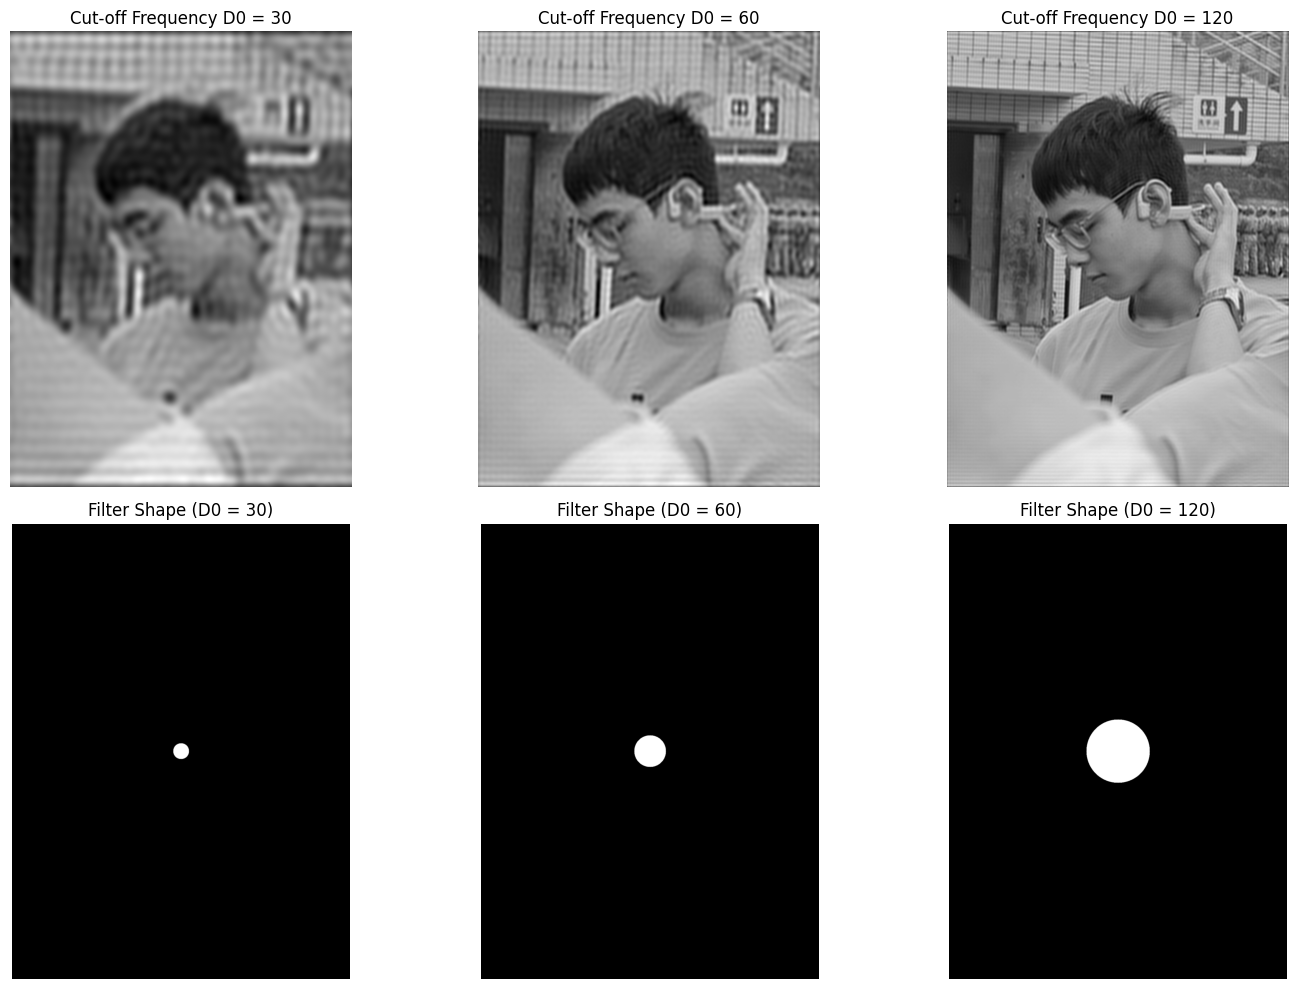

In [58]:
#理想低通频域滤波
import cv2
import numpy as np
import matplotlib.pyplot as plt

def ideal_low_pass_filter(shape, cutoff_frequency):
    """
    创建理想低通滤波器
    :变量1 shape: 图像形状 (rows, cols)
    :变量2 cutoff_frequency: 截止频率
    :return: 滤波器掩码
    """
    rows, cols = shape
    center_row, center_col = rows // 2, cols // 2
    
    #创建网格
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u, v, indexing='ij')
    
    #计算距离中心的欧氏距离
    distance = np.sqrt((u - center_row)**2 + (v - center_col)**2)
    
    #创建理想低通滤波器
    filter_mask = np.zeros_like(distance)
    filter_mask[distance <= cutoff_frequency] = 1
    
    return filter_mask

def apply_ideal_low_pass_filter(image, cutoff_frequency):
    """
    应用理想低通滤波器
    :参数1: image: 输入图像
    :参数2: cutoff_frequency: 截止频率
    :return: 滤波后的图像
    """
    rows, cols = image.shape
    
    #将图像转换为float32
    img_float32 = np.float32(image)
    
    #中心化
    mask = np.ones((rows, cols))
    mask[1::2, ::2] = -1
    mask[::2, 1::2] = -1
    centered_img = img_float32 * mask
    
    #进行傅里叶变换
    #获取最佳DFT大小
    optimal_rows = cv2.getOptimalDFTSize(rows)
    optimal_cols = cv2.getOptimalDFTSize(cols)
    
    #创建扩展的复数图像
    padded_img = np.zeros((optimal_rows, optimal_cols), dtype=np.float32)
    padded_img[:rows, :cols] = centered_img
    
    #进行DFT
    dft = cv2.dft(padded_img, flags=cv2.DFT_COMPLEX_OUTPUT)
    
    #创建并应用理想低通滤波器
    filter_mask = ideal_low_pass_filter((optimal_rows, optimal_cols), cutoff_frequency)
    
    #将滤波器应用于DFT结果
    dft_filtered = dft.copy()
    dft_filtered[:, :, 0] *= filter_mask
    dft_filtered[:, :, 1] *= filter_mask
    
    #进行逆傅里叶变换
    idft = cv2.idft(dft_filtered)
    filtered_img = idft[:, :, 0]
    
    #逆中心化
    mask_padded = np.ones((optimal_rows, optimal_cols))
    mask_padded[1::2, ::2] = -1
    mask_padded[::2, 1::2] = -1
    
    result_img = filtered_img * mask_padded
    
    #裁剪到原始大小
    final_result = result_img[:rows, :cols]
    
    #归一化到0-255范围
    final_result = cv2.normalize(final_result, None, 0, 255, cv2.NORM_MINMAX)
    final_result = np.uint8(final_result)
    
    return final_result

def main():
    image_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 3/xx.jpg' 
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError("图像文件未找到")
    
    #定义不同的截止频率
    cutoff_frequencies = [30, 60, 120]
    
    #创建图形显示结果
    plt.figure(figsize=(15, 10))
    
    #对每个截止频率应用理想低通滤波
    for i, cutoff in enumerate(cutoff_frequencies):
        print(f"应用截止频率为 {cutoff} 的理想低通滤波器...")
        
        #应用滤波器
        filtered_image = apply_ideal_low_pass_filter(image, cutoff)
        
        #显示结果
        plt.subplot(2, 3, i + 1)
        plt.imshow(filtered_image, cmap='gray')
        plt.title(f'Cut-off Frequency D0 = {cutoff}')
        plt.axis('off')
    
    #显示频域滤波器形状
    filter_shapes = []
    for cutoff in cutoff_frequencies:
        #创建滤波器形状用于显示
        shape = image.shape
        optimal_rows = cv2.getOptimalDFTSize(shape[0])
        optimal_cols = cv2.getOptimalDFTSize(shape[1])
        filter_mask = ideal_low_pass_filter((optimal_rows, optimal_cols), cutoff)
        filter_shapes.append(filter_mask)
    
    #显示滤波器形状
    for i, (filter_mask, cutoff) in enumerate(zip(filter_shapes, cutoff_frequencies)):
        plt.subplot(2, 3, i + 4)
        plt.imshow(filter_mask, cmap='gray')
        plt.title(f'Filter Shape (D0 = {cutoff})')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    

if __name__ == "__main__":
    main()

高斯低通频域滤波
图像尺寸: (1706, 1279)


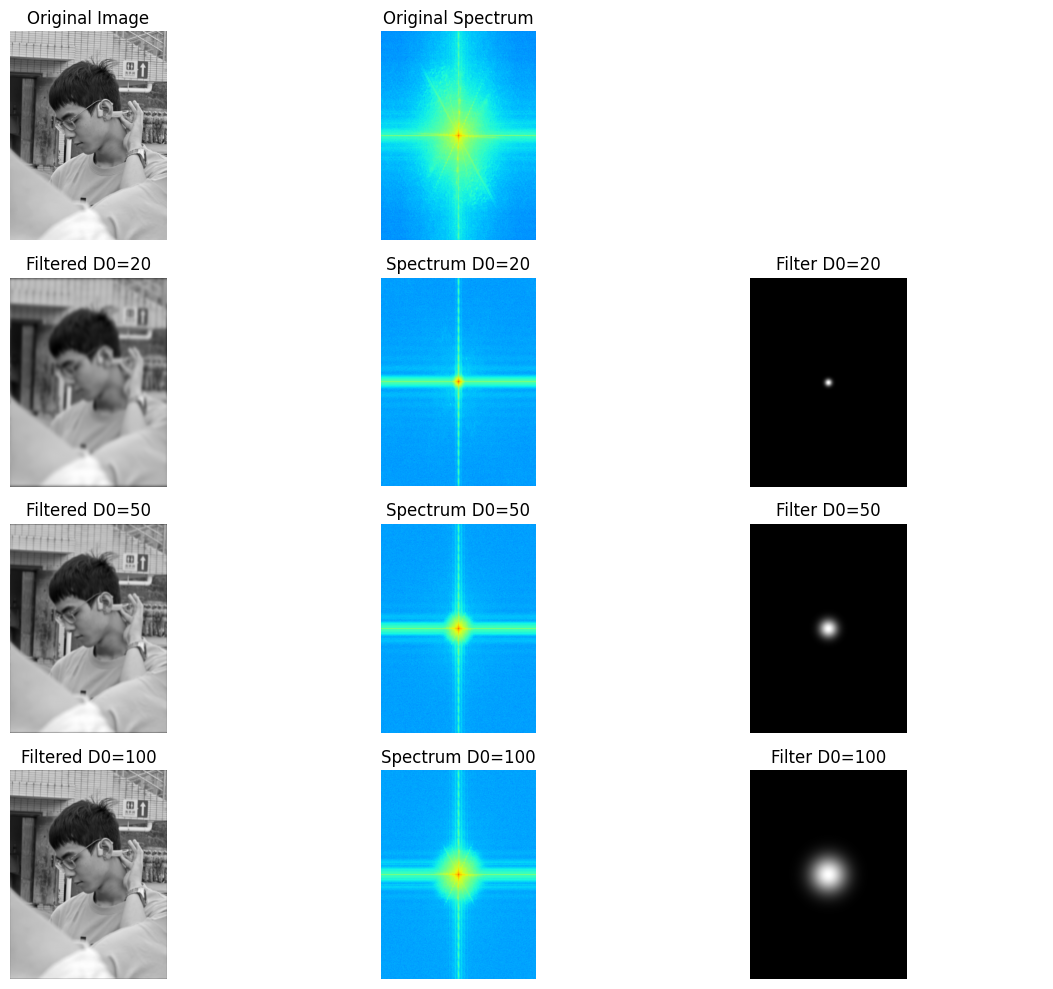

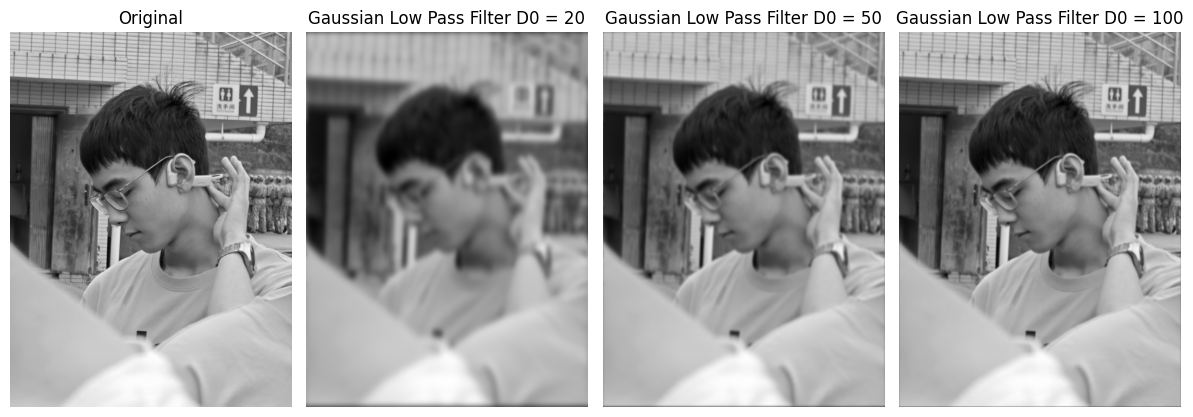

In [59]:
#高斯低通频率滤波
import cv2
import numpy as np
import matplotlib.pyplot as plt

def gaussian_low_pass_filter(shape, cutoff_frequency):
    """
    创建高斯低通滤波器
    :参数1 shape: 图像形状 (rows, cols)
    :参数2 cutoff_frequency: 截止频率
    :return: 滤波器掩码
    """
    rows, cols = shape
    center_row, center_col = rows // 2, cols // 2
    
    #创建网格
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u, v, indexing='ij')
    
    #计算距离中心的欧氏距离
    distance = np.sqrt((u - center_row)**2 + (v - center_col)**2)
    
    # 创建高斯低通滤波器
    # H(u,v) = exp(-D(u,v)² / (2 * D0²))
    filter_mask = np.exp(-(distance**2) / (2 * (cutoff_frequency**2)))
    
    return filter_mask

def apply_gaussian_low_pass_filter(image, cutoff_frequency):
    """
    应用高斯低通滤波器
    :参数1 image: 输入图像
    :参数2 cutoff_frequency: 截止频率
    :return: 滤波后的图像
    """
    rows, cols = image.shape
    
    #将图像转换为float32
    img_float32 = np.float32(image)
    
    #中心化
    mask = np.ones((rows, cols))
    mask[1::2, ::2] = -1
    mask[::2, 1::2] = -1
    centered_img = img_float32 * mask
    
    #进行傅里叶变换
    #获取最佳DFT大小
    optimal_rows = cv2.getOptimalDFTSize(rows)
    optimal_cols = cv2.getOptimalDFTSize(cols)
    
    #创建扩展的复数图像
    padded_img = np.zeros((optimal_rows, optimal_cols), dtype=np.float32)
    padded_img[:rows, :cols] = centered_img
    
    #进行DFT
    dft = cv2.dft(padded_img, flags=cv2.DFT_COMPLEX_OUTPUT)
    
    #创建并应用高斯低通滤波器
    filter_mask = gaussian_low_pass_filter((optimal_rows, optimal_cols), cutoff_frequency)
    
    #将滤波器应用于DFT结果
    dft_filtered = dft.copy()
    dft_filtered[:, :, 0] *= filter_mask
    dft_filtered[:, :, 1] *= filter_mask
    
    #进行逆傅里叶变换
    idft = cv2.idft(dft_filtered)
    filtered_img = idft[:, :, 0]

    #逆中心化
    mask_padded = np.ones((optimal_rows, optimal_cols))
    mask_padded[1::2, ::2] = -1
    mask_padded[::2, 1::2] = -1
    
    result_img = filtered_img * mask_padded
    
    #裁剪到原始大小
    final_result = result_img[:rows, :cols]
    
    #归一化到0-255范围
    final_result = cv2.normalize(final_result, None, 0, 255, cv2.NORM_MINMAX)
    final_result = np.uint8(final_result)
    
    return final_result

def display_frequency_spectrum(image, title=""):
    """
    显示图像的频谱
    """
    rows, cols = image.shape
    img_float32 = np.float32(image)
    
    #获取最佳DFT大小
    optimal_rows = cv2.getOptimalDFTSize(rows)
    optimal_cols = cv2.getOptimalDFTSize(cols)
    
    #创建扩展的复数图像
    padded_img = np.zeros((optimal_rows, optimal_cols), dtype=np.float32)
    padded_img[:rows, :cols] = img_float32
    
    #进行DFT
    dft = cv2.dft(padded_img, flags=cv2.DFT_COMPLEX_OUTPUT)
    
    #将零频率分量移到中心
    dft_shift = np.fft.fftshift(dft)
    
    #计算幅度谱
    magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)
    
    return magnitude_spectrum

def main():
    print("高斯低通频域滤波")
    print("=" * 40)

    image_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 3/xx.jpg'
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError("图像文件未找到，使用示例图像")

    print(f"图像尺寸: {image.shape}")

    cutoff_frequencies = [20, 50, 100]

    plt.figure(figsize=(12, 10))

    #原图及其频谱图
    plt.subplot(4, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    spectrum_original = display_frequency_spectrum(image)
    plt.subplot(4, 3, 2)
    plt.imshow(spectrum_original, cmap='jet')
    plt.title('Original Spectrum')
    plt.axis('off')

    #占位空图
    plt.subplot(4, 3, 3)
    plt.axis('off')

    #滤波图像+频谱+滤波器形状
    for i, cutoff in enumerate(cutoff_frequencies):
        filtered_image = apply_gaussian_low_pass_filter(image, cutoff)
        spectrum_filtered = display_frequency_spectrum(filtered_image)
        filter_shape = gaussian_low_pass_filter(image.shape, cutoff)

        row = i + 1  #从第2行开始

        #滤波图像
        plt.subplot(4, 3, row * 3 + 1)
        plt.imshow(filtered_image, cmap='gray')
        plt.title(f'Filtered D0={cutoff}')
        plt.axis('off')

        #滤波后频谱
        plt.subplot(4, 3, row * 3 + 2)
        plt.imshow(spectrum_filtered, cmap='jet')
        plt.title(f'Spectrum D0={cutoff}')
        plt.axis('off')

        #滤波器形状
        plt.subplot(4, 3, row * 3 + 3)
        plt.imshow(filter_shape, cmap='gray')
        plt.title(f'Filter D0={cutoff}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    #创建高斯滤波对比图
    plt.figure(figsize=(12, 8))
    
    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original')
    plt.axis('off')
    
    for i, cutoff in enumerate(cutoff_frequencies):
        filtered_image = apply_gaussian_low_pass_filter(image, cutoff)
        plt.subplot(1, 4, i + 2)
        plt.imshow(filtered_image, cmap='gray')
        plt.title(f'Gaussian Low Pass Filter D0 = {cutoff}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

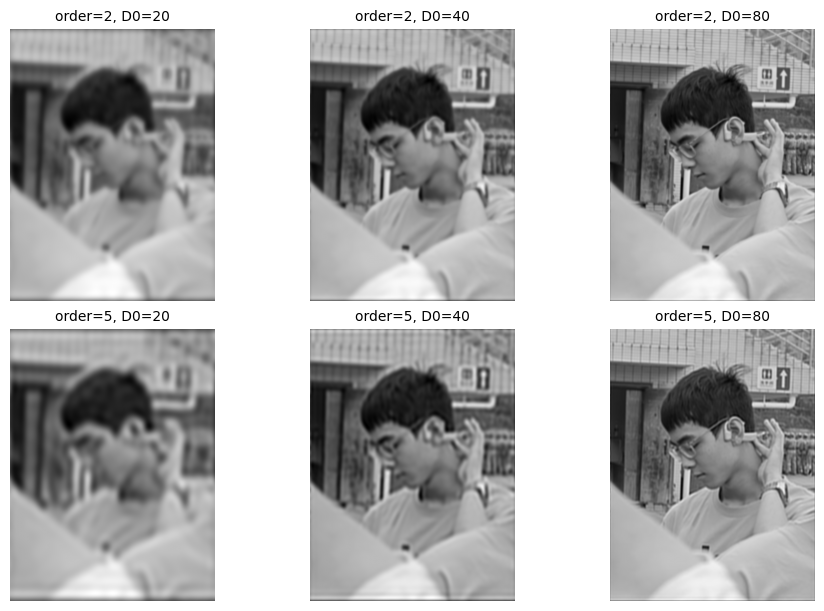

In [60]:
#巴特沃斯低通频率滤波
import cv2
import numpy as np
import matplotlib.pyplot as plt

#参数区
img_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 3/xx.jpg'
D0_list = [20, 40, 80] #截止频率
orders  = [2, 5] #阶数

def pad_to_optimal(img):
    """扩展成 FFT 最佳尺寸（2 的整数次幂）"""
    h, w = img.shape
    opt_h = cv2.getOptimalDFTSize(h)
    opt_w = cv2.getOptimalDFTSize(w)
    padded = cv2.copyMakeBorder(img, 0, opt_h-h, 0, opt_w-w, borderType=cv2.BORDER_CONSTANT, value=0)
    return padded, h, w

def butterworth_lowpass(shape, D0, n):
    """生成 n 阶 Butterworth 低通滤波器"""
    rows, cols = shape[:2]
    crow, ccol = rows//2, cols//2
    y, x = np.ogrid[:rows, :cols]
    dist_sq = (x - ccol)**2 + (y - crow)**2
    H = 1 / (1 + (dist_sq / (D0**2))**n)
    return H

def fft_filter(img, D0, n):
    """频域滤波并返回裁剪后的空域结果"""
    #补零
    padded, orig_h, orig_w = pad_to_optimal(img)
    ph, pw = padded.shape
    H = butterworth_lowpass((ph, pw), D0, n)
    #FFT
    dft = cv2.dft(np.float32(padded), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    #滤波
    filtered_dft = dft_shift * H[:,:,np.newaxis]
    #IFFT
    idft_shift = np.fft.ifftshift(filtered_dft)
    idft = cv2.idft(idft_shift)
    filtered = cv2.magnitude(idft[:,:,0], idft[:,:,1])
    #裁剪回原尺寸 + 归一化
    filtered = filtered[:orig_h, :orig_w]
    cv2.normalize(filtered, filtered, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(filtered)

#读图
gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
assert gray is not None, "图片读取失败，请检查路径"

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9, 6), constrained_layout=True)
axes = axes.flatten() #拉成一维

idx = 0
for i, n in enumerate(orders):
    for j, D0 in enumerate(D0_list):
        out = fft_filter(gray, D0, n)

        axes[idx].imshow(out, cmap='gray')
        axes[idx].set_title(f'order={n}, D0={D0}', fontsize=10)
        axes[idx].axis('off')
        idx += 1

plt.savefig('butterworth_results.jpg', dpi=300)
plt.show()

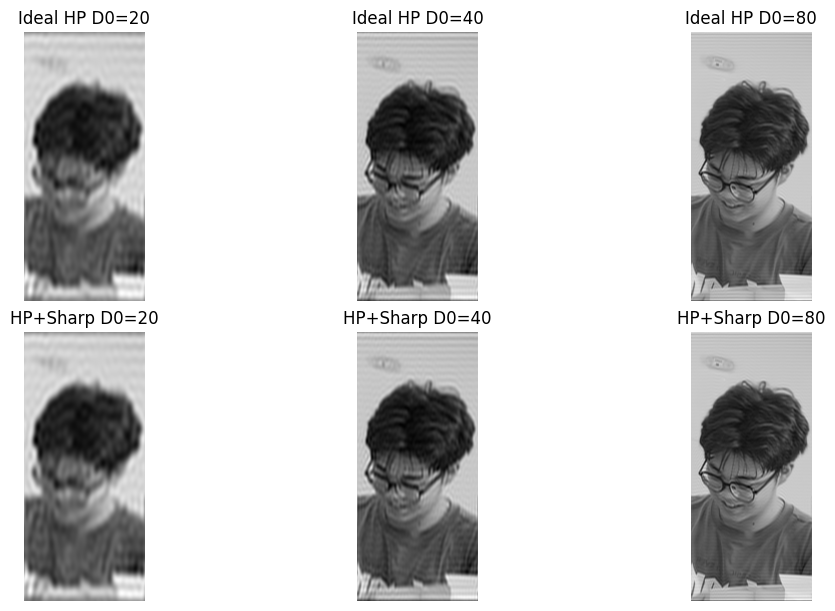

In [61]:
#理想高通频域滤波
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

img_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 3/lsy.jpg'
D0_list  = [20, 40, 80] #截止频率
alpha = 1.0 #锐化强度

def pad_to_optimal(img):
    h, w = img.shape
    opt_h = cv2.getOptimalDFTSize(h)
    opt_w = cv2.getOptimalDFTSize(w)
    padded = cv2.copyMakeBorder(img, 0, opt_h-h, 0, opt_w-w,borderType=cv2.BORDER_CONSTANT, value=0)
    return padded, h, w

def ideal_highpass(shape, D0):
    """理想高通滤波器：中心为 0，其余为 1"""
    h, w = shape[:2]
    cy, cx = h//2, w//2
    y, x = np.ogrid[:h, :w]
    mask = ((x - cx)**2 + (y - cy)**2) >= D0**2 #圆外=1，圆内=0
    return mask.astype(np.float32)

def freq_filter(img, D0, filter_func):
    """通用频域滤波：filter_func 返回 H(u,v)"""
    padded, orig_h, orig_w = pad_to_optimal(img)
    ph, pw = padded.shape
    H = filter_func((ph, pw), D0) #生成滤波器
    dft = cv2.dft(np.float32(padded), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    filtered = dft_shift * (1 - H)[:,:,np.newaxis] #高通 = 1 - 低通
    idft = cv2.idft(np.fft.ifftshift(filtered))
    out = cv2.magnitude(idft[:,:,0], idft[:,:,1])[:orig_h, :orig_w]
    cv2.normalize(out, out, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(out)

def unsharp_mask(img, alpha=1.0):
    """空域锐化：原图 + alpha*(原图 - 高斯模糊)"""
    blur = cv2.GaussianBlur(img, (9, 9), 2)
    sharp = cv2.addWeighted(img, 1+alpha, blur, -alpha, 0)
    return sharp

gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
assert gray is not None, "图片读取失败"

fig, ax = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
ax = ax.flatten()

for idx, D0 in enumerate(D0_list):
    #理想高通滤波
    hp = freq_filter(gray, D0, ideal_highpass)

    #锐化
    sharp = unsharp_mask(hp, alpha=alpha)
    
    #显示
    ax[idx].imshow(hp, cmap='gray')
    ax[idx].set_title(f'Ideal HP D0={D0}')
    ax[idx].axis('off')

    ax[idx+3].imshow(sharp, cmap='gray')
    ax[idx+3].set_title(f'HP+Sharp D0={D0}')
    ax[idx+3].axis('off')

plt.show()

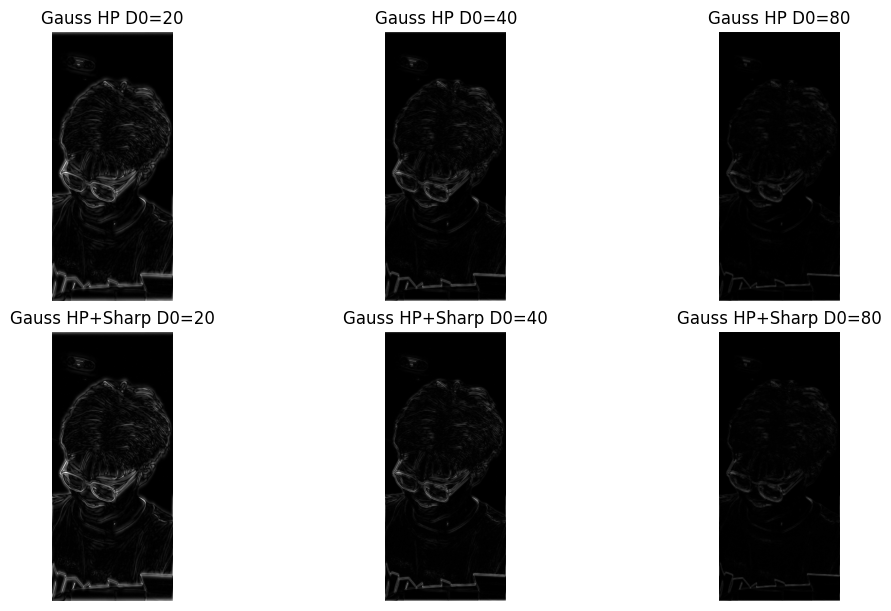

In [62]:
#高斯高通频域滤波
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

img_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 3/lsy.jpg'
D0_list = [20, 40, 80] #截止频率
alpha = 1.0 #锐化强度

def pad_to_optimal(img):
    h, w = img.shape
    opt_h = cv2.getOptimalDFTSize(h)
    opt_w = cv2.getOptimalDFTSize(w)
    padded = cv2.copyMakeBorder(img, 0, opt_h-h, 0, opt_w-w, borderType=cv2.BORDER_CONSTANT, value=0)
    return padded, h, w

def gauss_highpass(shape, D0):
    """高斯高通滤波器 H(u,v) = 1 - exp(-D²/2D0²)"""
    h, w = shape[:2]
    cy, cx = h//2, w//2
    y, x = np.ogrid[:h, :w]
    dist2 = (x - cx)**2 + (y - cy)**2
    H = 1 - np.exp(-dist2 / (2 * D0**2))
    return H.astype(np.float32)

def freq_filter(img, D0, filter_func):
    """通用频域滤波"""
    padded, orig_h, orig_w = pad_to_optimal(img)
    ph, pw = padded.shape
    H = filter_func((ph, pw), D0)
    dft = cv2.dft(np.float32(padded), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    filtered = dft_shift * H[:,:,np.newaxis]
    idft = cv2.idft(np.fft.ifftshift(filtered))
    out = cv2.magnitude(idft[:,:,0], idft[:,:,1])[:orig_h, :orig_w]
    cv2.normalize(out, out, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(out)

def unsharp_mask(img, alpha=1.0):
    blur = cv2.GaussianBlur(img, (9, 9), 2)
    sharp = cv2.addWeighted(img, 1+alpha, blur, -alpha, 0)
    return sharp

gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
assert gray is not None, "图片读取失败"

fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
axes = axes.flatten()

for idx, D0 in enumerate(D0_list):
    #高斯高通
    hp = freq_filter(gray, D0, gauss_highpass)

    #锐化
    sharp = unsharp_mask(hp, alpha=alpha)

    #显示
    axes[idx].imshow(hp, cmap='gray')
    axes[idx].set_title(f'Gauss HP D0={D0}')
    axes[idx].axis('off')

    axes[idx+3].imshow(sharp, cmap='gray')
    axes[idx+3].set_title(f'Gauss HP+Sharp D0={D0}')
    axes[idx+3].axis('off')

plt.show()

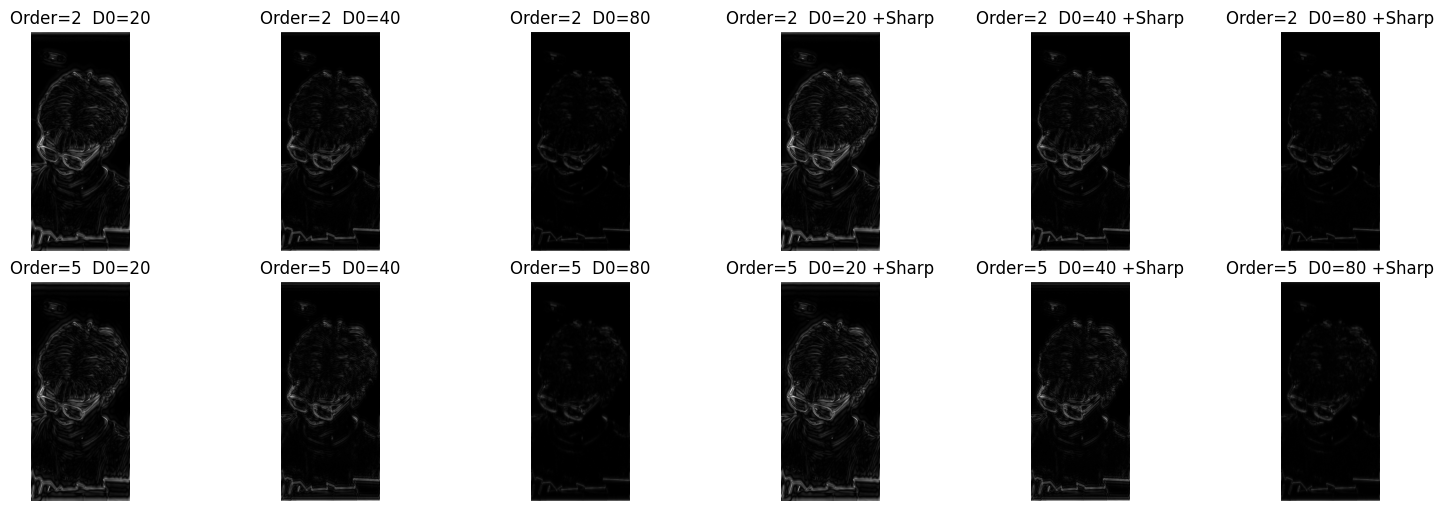

In [63]:
#巴特沃斯高通频率滤波
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

img_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 3/lsy.jpg'
D0_list = [20, 40, 80] #截止频率
orders = [2, 5] #阶数
alpha = 1.0 #锐化强度

def pad_to_optimal(img):
    h, w = img.shape
    opt_h = cv2.getOptimalDFTSize(h)
    opt_w = cv2.getOptimalDFTSize(w)
    padded = cv2.copyMakeBorder(img, 0, opt_h-h, 0, opt_w-w, borderType=cv2.BORDER_CONSTANT, value=0)
    return padded, h, w

def butterworth_highpass(shape, D0, n):
    """巴特沃斯高通：H(u,v) = 1 / (1 + (D0/D)^(2n))"""
    h, w = shape[:2]
    cy, cx = h//2, w//2
    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2)
    dist[dist == 0] = 1e-8 #防除0
    H = 1 / (1 + (D0 / dist)**(2 * n))
    return H.astype(np.float32)

def freq_filter(img, D0, n, filter_func):
    padded, orig_h, orig_w = pad_to_optimal(img)
    ph, pw = padded.shape
    H = filter_func((ph, pw), D0, n)
    dft = cv2.dft(np.float32(padded), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    filtered = dft_shift * H[:,:,np.newaxis]
    idft = cv2.idft(np.fft.ifftshift(filtered))
    out = cv2.magnitude(idft[:,:,0], idft[:,:,1])[:orig_h, :orig_w]
    cv2.normalize(out, out, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(out)

def unsharp_mask(img, alpha=1.0):
    blur = cv2.GaussianBlur(img, (9, 9), 2)
    sharp = cv2.addWeighted(img, 1+alpha, blur, -alpha, 0)
    return sharp

gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
assert gray is not None, "图片读取失败"

fig, axes = plt.subplots(2, 6, figsize=(15, 5), constrained_layout=True)

for row, n in enumerate(orders):
    for col, D0 in enumerate(D0_list):
        #巴特沃斯高通
        hp = freq_filter(gray, D0, n, butterworth_highpass)

        #锐化
        sharp = unsharp_mask(hp, alpha=alpha)

        #显示
        axes[row, col].imshow(hp, cmap='gray')
        axes[row, col].set_title(f'Order={n}  D0={D0}')
        axes[row, col].axis('off')

        axes[row, col+3].imshow(sharp, cmap='gray')
        axes[row, col+3].set_title(f'Order={n}  D0={D0} +Sharp')
        axes[row, col+3].axis('off')

plt.show()